In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


/home/dishad2/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# STEP 1: DOWNLOAD DATASET & CONFIGURATION

print("Checking and downloading GTSRB dataset via kagglehub...")
downloaded_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", downloaded_path)

TRAIN_DIR = os.path.join(downloaded_path, "Train")
TOTAL_CLASSES = 43
IMG_SIZE = (30, 30)

# Select GPU device if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using processing device: {device}")


Checking and downloading GTSRB dataset via kagglehub...
Path to dataset files: /home/dishad2/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Using processing device: cpu


In [ ]:
# STEP 2: LOAD RAW DATA & SPLIT

images_list = []
labels_list = []

print("\nParsing image folders locally...")
for i in range(TOTAL_CLASSES):
    class_folder = os.path.join(TRAIN_DIR, str(i))
    if not os.path.isdir(class_folder):
        continue
        
    all_images = os.listdir(class_folder)
    for img_name in all_images:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img_path = os.path.join(class_folder, img_name)
                
                # Ingest via OpenCV
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                
                images_list.append(img)
                labels_list.append(i)
            except Exception as e:
                pass

X_raw = np.array(images_list, dtype=np.uint8)
y_raw = np.array(labels_list, dtype=np.int64)

# Stratified split for balanced classes
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y_raw, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_raw
)



Parsing image folders locally...


In [ ]:
# STEP 3: DATA TRANSFORMS (WITH AUGMENTATION) & DATALOADERS

class TrafficSignDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Upgraded Training Transforms: Fixes overfitting by simulating angles and lighting
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(15),                         # Simulates camera tilt
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Simulates shadows/glare
    transforms.ToTensor(),                                 # Scales pixels to [0, 1]
])

# Validation Transforms: Clean images only, no modifications
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

train_dataset = TrafficSignDataset(X_train_raw, y_train, transform=train_transform)
val_dataset = TrafficSignDataset(X_val_raw, y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Train Dataset size: {len(train_dataset)}")
print(f"Validation Dataset size: {len(val_dataset)}")


Train Dataset size: 31367
Validation Dataset size: 7842


In [ ]:
# STEP 4: DEFINE CNN ARCHITECTURE

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(0.25)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = x.view(x.size(0), -1) # Flatten
        
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x) 
        return x

model = TrafficSignCNN(num_classes=TOTAL_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# STEP 5: TRAINING WITH EARLY STOPPING

epochs = 15 # Set higher since Early Stopping will stop it when optimized
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Early stopping tracking settings
best_val_loss = float('inf')
patience = 3
patience_counter = 0

print("\n--- Commencing model training routine ---")
for epoch in range(epochs):
    # Training Loop
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # Validation Loop
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    # Save statistics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")
    
    # Check Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Save the absolute best iteration weights to your local folder
        torch.save(model.state_dict(), 'best_traffic_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training at epoch {epoch+1}.")
            break

# Load the best saved model weights before evaluating/using the model
model.load_state_dict(torch.load('best_traffic_model.pth'))
print("Best model checkpoint loaded.")



--- Commencing model training routine ---
Epoch [1/15] -> Train Loss: 2.2999 | Train Acc: 34.63% | Val Loss: 0.5937 | Val Acc: 82.58%
Epoch [2/15] -> Train Loss: 0.6125 | Train Acc: 80.30% | Val Loss: 0.1308 | Val Acc: 96.66%
Epoch [3/15] -> Train Loss: 0.3227 | Train Acc: 89.71% | Val Loss: 0.0809 | Val Acc: 97.60%
Epoch [4/15] -> Train Loss: 0.2344 | Train Acc: 92.66% | Val Loss: 0.0506 | Val Acc: 98.60%
Epoch [5/15] -> Train Loss: 0.1870 | Train Acc: 94.13% | Val Loss: 0.0340 | Val Acc: 99.12%
Epoch [6/15] -> Train Loss: 0.1611 | Train Acc: 94.96% | Val Loss: 0.0262 | Val Acc: 99.26%
Epoch [7/15] -> Train Loss: 0.1400 | Train Acc: 95.72% | Val Loss: 0.0221 | Val Acc: 99.38%
Epoch [8/15] -> Train Loss: 0.1209 | Train Acc: 96.29% | Val Loss: 0.0179 | Val Acc: 99.54%
Epoch [9/15] -> Train Loss: 0.1114 | Train Acc: 96.40% | Val Loss: 0.0172 | Val Acc: 99.58%
Epoch [10/15] -> Train Loss: 0.1027 | Train Acc: 96.85% | Val Loss: 0.0101 | Val Acc: 99.67%
Epoch [11/15] -> Train Loss: 0.0898 

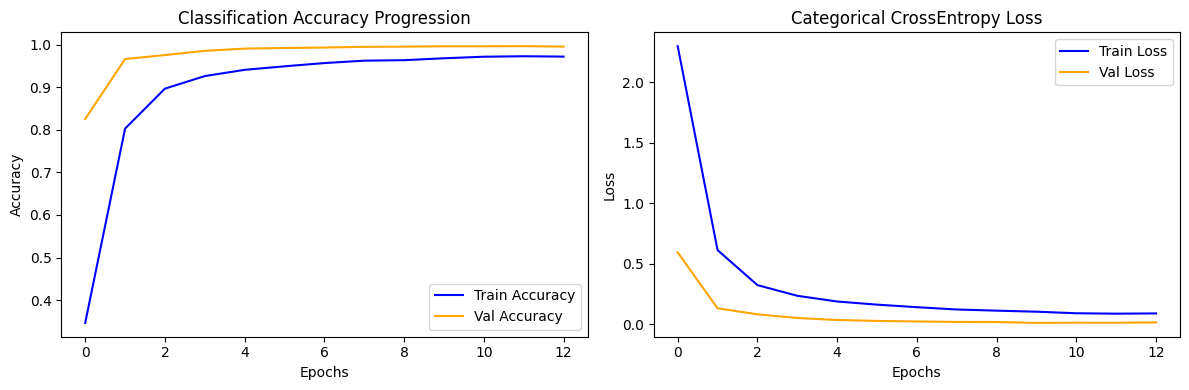

In [ ]:
# STEP 6: VISUAL DIAGNOSTIC METRIC PLOTTING

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
plt.title('Classification Accuracy Progression')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Categorical CrossEntropy Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# STEP 7: INDIVIDUAL TEST INFERENCE FUNCTION

def predict_single_image(model_path, image_path, target_device):
    """ Loads saved weights and runs prediction on an external image file """
    # Reinitialize model structure
    eval_model = TrafficSignCNN(num_classes=43).to(target_device)
    eval_model.load_state_dict(torch.load(model_path, map_location=target_device))
    eval_model.eval()
    
    # Load and clean image
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return None
        
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (30, 30))
    
    # Transform to normalized tensor format
    inference_transform = transforms.ToTensor()
    img_tensor = inference_transform(img).unsqueeze(0).to(target_device)
    
    with torch.no_grad():
        outputs = eval_model(img_tensor)
        _, predicted_class = torch.max(outputs, 1)
        
    return predicted_class.item()

print("\nCode block loaded. You can now use the predict_single_image() function below.")



Code block loaded. You can now use the predict_single_image() function below.


In [ ]:
# STEP 8: EVALUATE ON THE SEPARATE TEST DATASET

import pandas as pd

# Load the test metadata CSV file from the dataset
test_csv_path = os.path.join(downloaded_path, "Test.csv")

if os.path.exists(test_csv_path):
    print("Loading test dataset metadata...")
    test_df = pd.read_csv(test_csv_path)
    
    test_images = []
    test_labels = []
    
    # Iterate through the rows of the CSV to load test images
    print("Loading and preprocessing test images...")
    for idx, row in test_df.iterrows():
        # Path column contains relative path like 'Test/00000.png'
        img_path = os.path.join(downloaded_path, row['Path'])
        label = row['ClassId']
        
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (30, 30))
            
            test_images.append(img)
            test_labels.append(label)
        except Exception as e:
            pass
            
    X_test_raw = np.array(test_images, dtype=np.uint8)
    y_test = np.array(test_labels, dtype=np.int64)
    
    # Create DataLoader for Test Dataset
    test_dataset = TrafficSignDataset(X_test_raw, y_test, transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Run test evaluation
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    print(f"\n=========================================")
    print(f" FINAL TEST ACCURACY SCORE: {(correct / total) * 100:.2f}%")
    print(f"=========================================")
else:
    print(f"Could not find Test.csv at: {test_csv_path}")


Loading test dataset metadata...
Loading and preprocessing test images...

 FINAL TEST ACCURACY SCORE: 97.28%


Test image source: loaded image array (/home/dishad2/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Test/12629.png)
Predicted class: 10 -> Class 10
Ground truth class: 10 -> Class 10


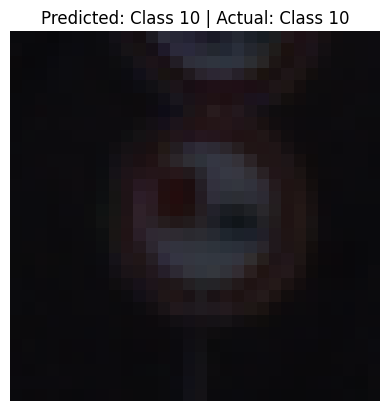

In [ ]:
# Single test image inference using the trained model
# If `img` and `img_path` are already available in notebook state, use them.
if 'img' in globals() and isinstance(img, np.ndarray):
    test_img = img
    source_desc = f"loaded image array ({img_path})" if 'img_path' in globals() else "loaded image array"
    true_label = label if 'label' in globals() else None
else:
    test_img_path = img_path if 'img_path' in globals() else os.path.join(downloaded_path, test_df.loc[0, 'Path'])
    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    source_desc = test_img_path
    true_label = label if 'label' in globals() else int(test_df.loc[0, 'ClassId'])

test_img_resized = cv2.resize(test_img, IMG_SIZE)
img_tensor = val_transform(test_img_resized).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    predicted_class = outputs.argmax(dim=1).item()

print(f"Test image source: {source_desc}")
print(f"Predicted class: {predicted_class}")
if true_label is not None:
    print(f"Ground truth class: {true_label}")

plt.imshow(test_img_resized)
plt.axis('off')
plt.title(f"Predicted: {predicted_class}" + (f" | Actual: {true_label}" if true_label is not None else ""))
plt.show()